# HF2LI Total Harmonic Distortion (THD) Measurement

Sweeps the drive frequency and simultaneously measures the **1st, 2nd, 3rd and 4th harmonics**
using four demodulators locked to the same oscillator. THD is calculated at each frequency point.

**Hardware connection:**
```
Signal Output 1  →  Device Under Test (DUT)  →  Signal Input 1
```
For a self-test (loopback), connect Output 1 directly to Input 1.

**Requirements:** HF2LI DEV182253 · USB · LabOne running locally · `zhinst-toolkit >= 22.02`

## 1. Imports

In [28]:
import time
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from zhinst.toolkit import Session

## 2. Parameters

Adjust these settings to match your setup before running.

In [29]:
DEVICE_ID = "DEV18253"         # HF2LI device ID (shown in LabOne GUI)

# --- Frequency sweep ----------------------------------------------------------
FREQ_START    = 1e3             # Sweep start frequency (Hz)
FREQ_STOP     = 10e6            # Sweep stop  frequency (Hz)
#   Keep FREQ_STOP < 50 MHz / NUM_HARMONICS so all harmonics stay within HF2LI range
NUM_POINTS    = 1001            # Number of frequency points
SWEEP_MAPPING = "log"           # "log" (recommended) or "linear"

# --- Signal output ------------------------------------------------------------
OUT_CHANNEL     = 0             # Signal output index (0 or 1)
OUT_MIXER_CH    = 0             # Mixer channel for the output — see note in cell below
DRIVE_AMPLITUDE = 0.5           # Drive amplitude (V peak) — keep within OUT_RANGE
OUT_RANGE       = 1.0           # Output range (V); options: 0.01, 0.1, 1.0, 10.0

# --- Signal input -------------------------------------------------------------
IN_CHANNEL = 0                  # Signal input index (0 or 1)
IN_RANGE   = 1.0                # Input range (V); set just above expected signal level
IN_AC      = 1                  # 0 = DC coupling, 1 = AC coupling
IN_IMP50   = 0                  # 0 = 1 MΩ input, 1 = 50 Ω input

# --- Demodulators (one per harmonic) -----------------------------------------
OSC_INDEX     = 0               # Oscillator to sweep (0–5 on HF2LI)
NUM_HARMONICS = 4               # Harmonics to measure: 1st, 2nd, 3rd, 4th
DEMOD_TC      = 10e-3           # Filter time constant (s); shorter = faster, noisier
DEMOD_ORDER   = 4               # Filter order (1–8)
DEMOD_RATE    = 100             # Demodulator sample rate (Sa/s)

# --- Sweeper settling and averaging ------------------------------------------
SETTLE_TIME_TC    = 10          # Settle time in multiples of filter TC
SETTLE_INACCURACY = 1e-3        # Settle inaccuracy threshold (0.001 = 0.1 %)
AVG_SAMPLES       = 1           # Number of samples to average per point
AVG_TIME_TC       = 5           # Averaging time in multiples of filter TC
BW_CONTROL        = 1           # 1 = auto-adjust filter BW with frequency (recommended for log sweeps)

# --- Output ------------------------------------------------------------------
SAVE_CSV  = True                # Save results to a CSV file
SAVE_PLOT = True                # Save the plot as PNG
OUTPUT_DIR = Path(".")          # Directory for saved files

## 3. Connect to HF2LI

`hf2=True` is required — the HF2LI uses its own data server on port 8005,
separate from other ZI instruments.

In [30]:
server_host ='localhost'
## connect to data server
session = Session(server_host,hf2=True)
device = session.connect_device(DEVICE_ID)
## connect to device

print(f"Connected to {DEVICE_ID}")
print(f"Sweep: {FREQ_START:.0f} – {FREQ_STOP:.0f} Hz  |  {NUM_POINTS} points  |  {SWEEP_MAPPING}")
print(f"Harmonics: 1 – {NUM_HARMONICS}")

Connected to DEV18253
Sweep: 1000 – 10000000 Hz  |  1001 points  |  log
Harmonics: 1 – 4


## 4. Configure Signal Output and Input

The output drives the DUT at the fundamental frequency. The oscillator frequency
will be controlled by the sweeper module in the next steps.

> **Note on `OUT_MIXER_CH`:** For HF2LI, mixer channel 0 drives the output using
> oscillator 0. If no signal appears at the output, open the LabOne GUI → Output tab
> and check which mixer channel is enabled for your oscillator.

In [31]:
with device.set_transaction():
    device.oscs[OSC_INDEX].freq(FREQ_START)             # set initial frequency

    device.sigouts[OUT_CHANNEL].range(OUT_RANGE)
    device.sigouts[OUT_CHANNEL].amplitudes[OUT_MIXER_CH](DRIVE_AMPLITUDE)
    device.sigouts[OUT_CHANNEL].enables[OUT_MIXER_CH](True)
    device.sigouts[OUT_CHANNEL].on(True)

    device.sigins[IN_CHANNEL].range(IN_RANGE)
    device.sigins[IN_CHANNEL].ac(IN_AC)
    device.sigins[IN_CHANNEL].imp50(IN_IMP50)

print(f"Output ON  |  amplitude = {DRIVE_AMPLITUDE} V  |  range = ±{OUT_RANGE} V")

Output ON  |  amplitude = 0.5 V  |  range = ±1.0 V


## 5. Configure Demodulators

All four demodulators are locked to the **same oscillator** (`OSC_INDEX`).
The `harmonic` node tells each demod to measure at a multiple of the oscillator frequency:

| Demod | Harmonic | Measures at |
|-------|----------|-------------|
| 0 | 1 | 1 × f_drive (fundamental) |
| 1 | 2 | 2 × f_drive |
| 2 | 3 | 3 × f_drive |
| 3 | 4 | 4 × f_drive |

When the sweeper changes the oscillator frequency, all four reference frequencies
update automatically — no manual reconfiguration needed at each frequency step.

In [32]:
with device.set_transaction():
    for i in range(NUM_HARMONICS):
        device.demods[i].enable(1)
        device.demods[i].oscselect(OSC_INDEX)
        device.demods[i].harmonic(i + 1)        # 1, 2, 3, 4
        device.demods[i].adcselect(IN_CHANNEL)
        device.demods[i].order(DEMOD_ORDER)
        device.demods[i].timeconstant(DEMOD_TC)
        device.demods[i].rate(DEMOD_RATE)
        device.demods[i].phaseshift(0.0)

suffixes = ["st", "nd", "rd", "th"]
for i in range(NUM_HARMONICS):
    print(f"  Demod {i}  →  {i+1}{suffixes[i]} harmonic  ({i+1} × f_drive)")

  Demod 0  →  1st harmonic  (1 × f_drive)
  Demod 1  →  2nd harmonic  (2 × f_drive)
  Demod 2  →  3rd harmonic  (3 × f_drive)
  Demod 3  →  4th harmonic  (4 × f_drive)


## 6. Configure Sweeper

The sweeper module steps the oscillator frequency across the defined range and
records the output of all four subscribed demodulators at each point.

- **Settling:** at each new frequency, the sweeper waits for the demodulator filter
  to settle before recording — controlled by `SETTLE_TIME_TC` and `SETTLE_INACCURACY`.
- **Auto bandwidth (`BW_CONTROL=1`):** scales the filter TC with frequency so the
  frequency resolution stays constant — essential for wide logarithmic sweeps.

In [33]:
sweeper = session.modules.sweeper
sweeper.device(device)

sweeper.gridnode(f"/{DEVICE_ID}/oscs/{OSC_INDEX}/freq")
sweeper.start(FREQ_START)
sweeper.stop(FREQ_STOP)
sweeper.samplecount(NUM_POINTS)
sweeper.xmapping(1 if SWEEP_MAPPING == "log" else 0)    # 0 = linear, 1 = log

sweeper.settling.tc(SETTLE_TIME_TC)
sweeper.settling.inaccuracy(SETTLE_INACCURACY)

sweeper.averaging.tc(AVG_TIME_TC)
sweeper.averaging.sample(AVG_SAMPLES)

sweeper.bandwidthcontrol(BW_CONTROL)

# Subscribe all four demodulator sample nodes
for i in range(NUM_HARMONICS):
    sweeper.subscribe(f"/{DEVICE_ID}/demods/{i}/sample")

print("Sweeper configured and subscriptions set.")

Sweeper configured and subscriptions set.


## 7. Run Sweep

In [34]:
print(f"Starting sweep  ({NUM_POINTS} points, TC = {DEMOD_TC*1e3:.1f} ms, settle = {SETTLE_TIME_TC} × TC)")
sweeper.execute()
t0 = time.time()

# sweeper.finished() is not available in newer zhinst.core (26.x) where
# daq.sweep() returns a toolkit-wrapped module — use wait_done() instead
sweeper.wait_done(timeout=3600)

print(f"Sweep complete in {time.time()-t0:.1f} s")

data = sweeper.read()       # no argument in toolkit-wrapped sweeper
sweeper.finish()
sweeper.unsubscribe("*")

Starting sweep  (1001 points, TC = 10.0 ms, settle = 10 × TC)
Sweep complete in 46.8 s


## 8. Extract Results

`sweeper.read()` returns a dict keyed by node path. Each entry is a nested list:
`data[node][0][0]` gives the result dict with keys `"grid"` (frequency axis),
`"r"` (amplitude), `"phase"`, `"x"`, `"y"`.

In [35]:
freq_axis  = None
amplitudes = {}     # {harmonic_number: np.array}

for i in range(NUM_HARMONICS):
    node_key      = f"/{DEVICE_ID.lower()}/demods/{i}/sample"
    result        = data[node_key][0][0]
    freq_axis     = result["grid"]
    amplitudes[i + 1] = result["r"]

print(f"{len(freq_axis)} points  |  {freq_axis[0]:.1f} – {freq_axis[-1]:.1f} Hz")
for n in range(1, NUM_HARMONICS + 1):
    print(f"  Harmonic {n}: mean amplitude = {np.mean(amplitudes[n])*1e3:.3f} mV")

1001 points  |  1000.0 – 10000000.0 Hz
  Harmonic 1: mean amplitude = 423.068 mV
  Harmonic 2: mean amplitude = 0.147 mV
  Harmonic 3: mean amplitude = 0.146 mV
  Harmonic 4: mean amplitude = 0.025 mV


## 9. Calculate THD

$$\mathrm{THD} = \frac{\sqrt{V_2^2 + V_3^2 + V_4^2}}{V_1} \times 100\,\%$$

where $V_1$ is the fundamental amplitude and $V_2$–$V_4$ are the harmonic amplitudes.

In [36]:
V1  = amplitudes[1]
THD = 100.0 * np.sqrt(sum(amplitudes[n]**2 for n in range(2, NUM_HARMONICS + 1))) / V1

print(f"THD summary:")
print(f"  Mean : {np.mean(THD):.3f} %")
print(f"  Min  : {np.min(THD):.3f} %  at {freq_axis[np.argmin(THD)]:.1f} Hz")
print(f"  Max  : {np.max(THD):.3f} %  at {freq_axis[np.argmax(THD)]:.1f} Hz")

THD summary:
  Mean : 0.052 %
  Min  : 0.010 %  at 5105.0 Hz
  Max  : 0.339 %  at 1047.1 Hz


## 10. Plot Results

Plot saved → THD_DEV18253.png


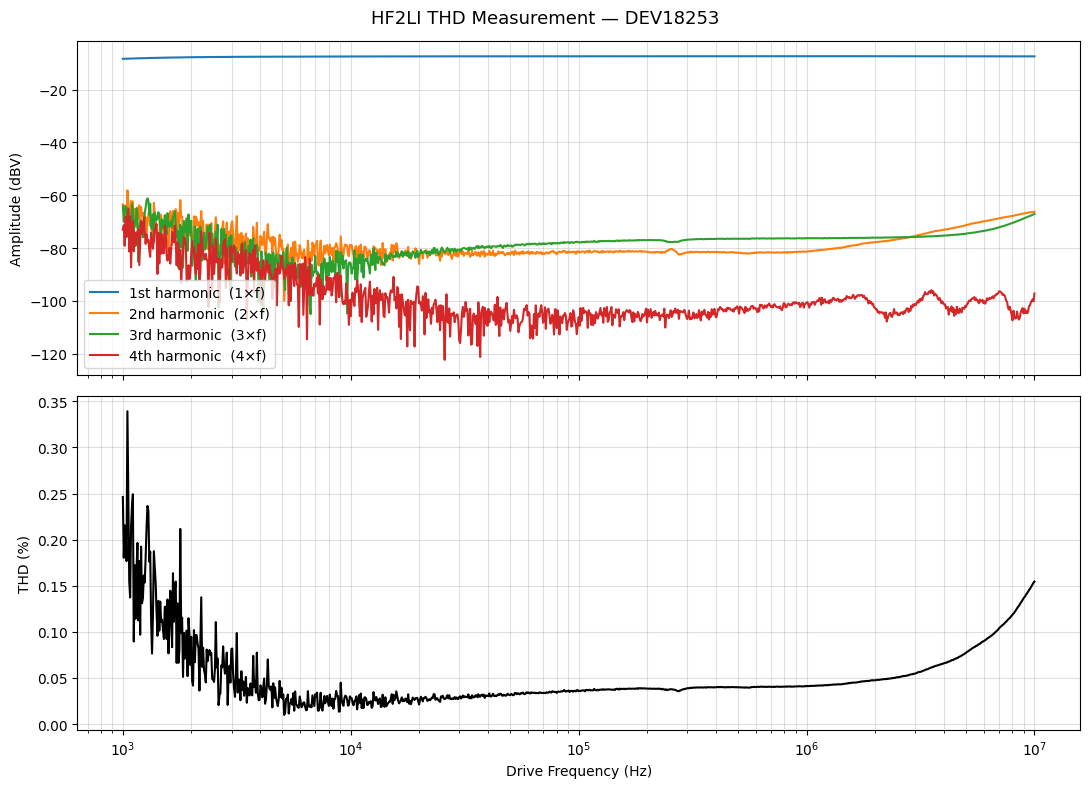

In [37]:
COLORS   = ["tab:blue", "tab:orange", "tab:green", "tab:red"]
SUFFIXES = ["st", "nd", "rd", "th"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
fig.suptitle(f"HF2LI THD Measurement — {DEVICE_ID}", fontsize=13)

for n in range(1, NUM_HARMONICS + 1):
    ax1.plot(
        freq_axis,
        20 * np.log10(amplitudes[n] + 1e-12),
        color=COLORS[n - 1],
        label=f"{n}{SUFFIXES[n-1]} harmonic  ({n}×f)"
    )
ax1.set_ylabel("Amplitude (dBV)")
ax1.legend()
ax1.grid(True, which="both", alpha=0.4)

ax2.plot(freq_axis, THD, color="black", linewidth=1.5)
ax2.set_ylabel("THD (%)")
ax2.set_xlabel("Drive Frequency (Hz)")
ax2.grid(True, which="both", alpha=0.4)

if SWEEP_MAPPING == "log":
    ax1.set_xscale("log")
    ax2.set_xscale("log")

plt.tight_layout()

if SAVE_PLOT:
    plot_path = OUTPUT_DIR / f"THD_{DEVICE_ID}.png"
    plt.savefig(plot_path, dpi=150)
    print(f"Plot saved → {plot_path}")

plt.show()

## 11. Save Data to CSV

In [ ]:
if SAVE_CSV:
    csv_path = OUTPUT_DIR / f"THD_{DEVICE_ID}.csv"
    header = "frequency_Hz," + ",".join(f"harmonic_{n}_V" for n in range(1, NUM_HARMONICS + 1)) + ",THD_percent"
    rows   = np.column_stack(
        [freq_axis] + [amplitudes[n] for n in range(1, NUM_HARMONICS + 1)] + [THD]
    )
    np.savetxt(csv_path, rows, delimiter=",", header=header, comments="")
    print(f"Data saved → {csv_path}")

## 12. Cleanup

In [ ]:
device.sigouts[OUT_CHANNEL].on(False)
print("Output off. Done.")